# ITI113 - Baseline Experiments with SageMaker Serverless MLflow App

1. Configure the Experiment Environment
2. Verify MLflow Access and connect to SageMaker MLflow App
3. EDA
   3.1 EDA Dedicated data-quality and leakage audit
   3.2 EDA Analysis: Numeric feature correlation with Fraud_Label
   3.3 EDA Visualization Analysis: Target class distribution
5. EDA Interpretation of the explicit rule audit
6. Feature Engineering : Deployable feature policy, Timestamp remediation and `Is_Weekend` consistency check
7. Stratified Random 60/20/20 train-validation-test split and save datasets to S3
8. Model Preprocessing : Common preprocessing, Evaluation and MLflow helpers
9. Baseline Heuristic used only as a benchmark; the exact target rule is diagnostic only
10. Model A: Logistic Regression (Trains and validates four candidates)
11. Model B: Tuned XGBoost (Trains and validates six  candidates)
12. Compares candidates, selects the champion and fixes its threshold
13. Visual analysis: model selection and operating-threshold trade-off
14. Final Champion Evaluation on the Held-Out Test Dataset and Error Analysis on Confusion Matrix 
15. Export the champion for Automated Training, Registry & Deployment Pipeline and print summary results

In [1]:
# Restart the kernel if packages were upgraded.
%pip install --quiet --upgrade "sagemaker>=2,<3" boto3 botocore mlflow sagemaker-mlflow xgboost scikit-learn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
autogluon-core 1.5.0 requires scikit-learn<1.8.0,>=1.4.0, but you have scikit-learn 1.9.0 which is incompatible.
autogluon-features 1.5.0 requires scikit-learn<1.8.0,>=1.4.0, but you have scikit-learn 1.9.0 which is incompatible.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.6.0 which is incompatible.
autogluon-multimodal 1.5.0 requires scikit-learn<1.8.0,>=1.4.0, but you have scikit-learn 1.9.0 which is incompatible.
autogluon-tabular 1.5.0 requ

## 1. Configure the Experiment Environment 
- Initialize Project Settings, Dataset Paths, and MLflow Tracking

In [2]:
import io
import json
import tempfile
from pathlib import Path

import boto3
import numpy as np
import pandas as pd
import sagemaker

REGION = "ap-southeast-1"
COURSE = "ITI113"
SEMESTER = "26S1"
TEAM_ID = "team07"
STUDENT_ID = "s701"
PROJECT_NAME = "credit-card-fraud-detection"

DATASET_PATH = Path("data/fraud_dataset.csv")
RAW_DATASET_VERSION = "fraud_dataset_50k_v1"
PROCESSED_DATASET_VERSION = "fraud_features_v2"

# Replace this placeholder with the actual dataset webpage/repository URL before submission.
DATASET_SOURCE_URL = "https://www.kaggle.com/datasets/samayashar/fraud-detection-transactions-dataset"
TARGET_COLUMN = "Fraud_Label"

CLASS_BUCKET = "nyp-26s1-iti113"
RAW_DATA_STORE_PREFIX = f"iti113/{TEAM_ID}/data/{RAW_DATASET_VERSION}/raw"
PROCESSED_DATA_STORE_PREFIX = f"iti113/{TEAM_ID}/data/{PROCESSED_DATASET_VERSION}/processed"
RANDOM_STATE = 42
VALIDATION_FPR_TARGET = 0.04
MAX_FALSE_POSITIVE_RATE = 0.05
MIN_ACCEPTABLE_RECALL = 0.60
# The probability cut-off is not fixed here. It is learned on validation data by
# maximizing recall at a 4% validation FPR target. This provides a generalisation
# margin while the final deployment FPR gate remains fixed at 5%.
GATE_RATIONALE = (
    "The original 0.70 recall gate was not feasible after excluding leakage-prone "
    "Risk_Score. Threshold selection uses a 0.04 validation FPR target to provide a "
    "generalisation margin. The prototype recall gate remains 0.60 and the final "
    "deployment FPR gate remains capped at 0.05."
)

session = boto3.Session(region_name=REGION)
sm = session.client("sagemaker")
s3 = session.client("s3")
role = sagemaker.get_execution_role()

config_candidates = [
    Path(f"mlflow_app_config_{TEAM_ID}.json"),
    Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json"),
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]
mlflow_config = {}
config_used = None
for candidate in config_candidates:
    if candidate.exists():
        mlflow_config = json.loads(candidate.read_text(encoding="utf-8"))
        config_used = candidate
        break
if not mlflow_config:
    raise FileNotFoundError("Run Notebook 01 and copy its MLflow configuration file here.")

MLFLOW_APP_ARN = mlflow_config.get("MLFLOW_APP_ARN")
MLFLOW_EXPERIMENT = mlflow_config.get("EXPERIMENT_NAME", f"{COURSE}/{TEAM_ID}/Experiment1")
if not MLFLOW_APP_ARN:
    raise ValueError(f"MLFLOW_APP_ARN is missing from {config_used}")

print("Dataset:", DATASET_PATH)
print("Raw dataset version:", RAW_DATASET_VERSION)
print("Processed dataset version:", PROCESSED_DATASET_VERSION)
print("MLflow experiment:", MLFLOW_EXPERIMENT)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Dataset: data/fraud_dataset.csv
Raw dataset version: fraud_dataset_50k_v1
Processed dataset version: fraud_features_v2
MLflow experiment: ITI113/team07/Experiment1


## 2. Verify MLflow Access and connect to SageMaker MLflow App
The shared tags defined here make every run traceable to its course, team, student, project, dataset versions, split strategy, and quality-gate targets.

In [3]:
import mlflow
import mlflow.sklearn

tags = {item["Key"]: item["Value"] for item in sm.list_tags(ResourceArn=MLFLOW_APP_ARN).get("Tags", [])}
if tags.get("TeamId") != TEAM_ID:
    raise PermissionError(f"MLflow App TeamId={tags.get('TeamId')} does not match {TEAM_ID}.")

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
experiment = mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "dataset_version": RAW_DATASET_VERSION,  # Notebook 3 compatibility
    "raw_dataset_version": RAW_DATASET_VERSION,
    "processed_dataset_version": PROCESSED_DATASET_VERSION,
    "problem_type": "imbalanced_binary_classification",
    "selection_objective": "recall_at_validation_fpr_target",
    "validation_fpr_target": str(VALIDATION_FPR_TARGET),
    "maximum_fpr": str(MAX_FALSE_POSITIVE_RATE),
    "minimum_acceptable_recall": str(MIN_ACCEPTABLE_RECALL),
    "split_strategy": "stratified_random_60_20_20",
}
print("MLflow experiment tracking is ready.")
print(f"  Team ownership verified : {tags.get('TeamId')}")
print(f"  Experiment name        : {MLFLOW_EXPERIMENT}")
print(f"  Experiment ID          : {experiment.experiment_id}")
print(f"  Raw dataset version    : {RAW_DATASET_VERSION}")
print(f"  Processed data version : {PROCESSED_DATASET_VERSION}")
print(f"  Selection objective    : recall at validation FPR ≤ {VALIDATION_FPR_TARGET:.1%}")
print("  Shared run tags        : configured")

MLflow experiment tracking is ready.
  Team ownership verified : team07
  Experiment name        : ITI113/team07/Experiment1
  Experiment ID          : 1
  Raw dataset version    : fraud_dataset_50k_v1
  Processed data version : fraud_features_v2
  Selection objective    : recall at validation FPR ≤ 4.0%
  Shared run tags        : configured


## 3.1 Dedicated data-quality and leakage audit


This section runs before modelling. It checks schema, missing values, duplicates, target balance, timestamp validity, supplied weekend consistency, and the apparent deterministic target rule.

In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATASET_PATH}. Rename the supplied fraud_dataset(1).csv to fraud_dataset.csv "
        "and place it in the data/ folder."
    )

raw_df = pd.read_csv(DATASET_PATH)
# Display a sample of the raw dataset
print("Dataset shape:", raw_df.shape)

print("\nDataset columns:")
print(raw_df.columns.tolist())

print("\nFirst 5 raw records:")
display(raw_df.head(5))

print("\nColumn data types:")
display(raw_df.dtypes.astype(str).rename("data_type").to_frame())

# Continue with the data-quality checks
required_columns = {
    "Transaction_ID", "User_ID", "Transaction_Amount", "Transaction_Type",
    "Timestamp", "Account_Balance", "Device_Type", "Location",
    "Merchant_Category", "IP_Address_Flag", "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count", "Avg_Transaction_Amount_7d",
    "Failed_Transaction_Count_7d", "Card_Type", "Card_Age",
    "Transaction_Distance", "Authentication_Method", "Risk_Score",
    "Is_Weekend", TARGET_COLUMN,
}
missing_columns = required_columns - set(raw_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

parsed_timestamp = pd.to_datetime(raw_df["Timestamp"], errors="coerce")
derived_weekend = (parsed_timestamp.dt.dayofweek >= 5).astype("Int64")
weekend_mismatch = int((derived_weekend != raw_df["Is_Weekend"]).fillna(True).sum())

suspected_rule = (
    (raw_df["Risk_Score"] > 0.85)
    | (raw_df["Failed_Transaction_Count_7d"] >= 4)
).astype(int)
rule_match_rate = float((suspected_rule == raw_df[TARGET_COLUMN]).mean())

target_counts = raw_df[TARGET_COLUMN].value_counts().sort_index()
fraud_count = int(target_counts.get(1, 0))
nonfraud_count = int(target_counts.get(0, 0))
fraud_rate = float(raw_df[TARGET_COLUMN].mean())
imbalance_ratio = float(nonfraud_count / fraud_count)

audit_summary = {
    "raw_dataset_version": RAW_DATASET_VERSION,
    "source_url": DATASET_SOURCE_URL,
    "rows": int(len(raw_df)),
    "columns": int(raw_df.shape[1]),
    "missing_values": int(raw_df.isna().sum().sum()),
    "duplicate_rows": int(raw_df.duplicated().sum()),
    "unique_transaction_ids": int(raw_df["Transaction_ID"].nunique()),
    "unique_users": int(raw_df["User_ID"].nunique()),
    "invalid_timestamps": int(parsed_timestamp.isna().sum()),
    "weekend_mismatch_rows": weekend_mismatch,
    "weekend_mismatch_rate": float(weekend_mismatch / len(raw_df)),
    "fraud_count": fraud_count,
    "nonfraud_count": nonfraud_count,
    "fraud_rate": fraud_rate,
    "nonfraud_to_fraud_ratio": imbalance_ratio,
    "explicit_rule_match_rate": rule_match_rate,
    "explicit_rule": "Risk_Score > 0.85 OR Failed_Transaction_Count_7d >= 4",
}

display(pd.DataFrame({
    "count": target_counts,
    "rate": raw_df[TARGET_COLUMN].value_counts(normalize=True).sort_index(),
}).rename(index={0: "Non-fraud", 1: "Fraud"}))
print(json.dumps(audit_summary, indent=2))

if rule_match_rate >= 0.95:
    print("[LEAKAGE WARNING] The explicit rule reconstructs almost all target labels.")
if weekend_mismatch > 0:
    print("[DATA QUALITY WARNING] Supplied Is_Weekend conflicts with Timestamp; it will be replaced.")

Path("data_quality_and_leakage_audit.json").write_text(json.dumps(audit_summary, indent=2), encoding="utf-8")

Dataset shape: (50000, 21)

Dataset columns:
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Timestamp', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age', 'Transaction_Distance', 'Authentication_Method', 'Risk_Score', 'Is_Weekend', 'Fraud_Label']

First 5 raw records:


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1



Column data types:


,data_type
Transaction_ID,object
User_ID,object
Transaction_Amount,float64
Transaction_Type,object
Timestamp,object
Account_Balance,float64
Device_Type,object
Location,object
Merchant_Category,object
IP_Address_Flag,int64


,count,rate
Fraud_Label,,
Non-fraud,33933,0.67866
Fraud,16067,0.32134


{
  "raw_dataset_version": "fraud_dataset_50k_v1",
  "source_url": "https://www.kaggle.com/datasets/samayashar/fraud-detection-transactions-dataset",
  "rows": 50000,
  "columns": 21,
  "missing_values": 0,
  "duplicate_rows": 0,
  "unique_transaction_ids": 50000,
  "unique_users": 8963,
  "invalid_timestamps": 0,
  "weekend_mismatch_rows": 20755,
  "weekend_mismatch_rate": 0.4151,
  "fraud_count": 16067,
  "nonfraud_count": 33933,
  "fraud_rate": 0.32134,
  "nonfraud_to_fraud_ratio": 2.111968631356196,
  "explicit_rule_match_rate": 1.0,
  "explicit_rule": "Risk_Score > 0.85 OR Failed_Transaction_Count_7d >= 4"
}
[LEAKAGE WARNING] The explicit rule reconstructs almost all target labels.
[DATA QUALITY WARNING] Supplied Is_Weekend conflicts with Timestamp; it will be replaced.


620

## 3.2 EDA Analysis: Numeric feature correlation with Fraud_Label

Pearson correlation measures the strength of a linear relationship between each numeric feature and the binary fraud label. It is descriptive rather than causal, and a near-zero value does not rule out a nonlinear relationship. `Risk_Score` is shown for audit transparency but remains excluded from modelling because the leakage audit indicates that it helps reconstruct the target.

In [5]:
numeric_df = raw_df.select_dtypes(include=[np.number])

numeric_correlations = (
    numeric_df.corr(method="pearson")[TARGET_COLUMN]
    .drop(labels=[TARGET_COLUMN])
    .rename("Correlation with Fraud_Label")
    .to_frame()
)
numeric_correlations["Absolute correlation"] = (
    numeric_correlations["Correlation with Fraud_Label"].abs()
)
numeric_correlations = numeric_correlations.sort_values(
    "Absolute correlation", ascending=False
)

def interpret_correlation(value):
    magnitude = abs(value)
    direction = "positive" if value > 0 else "negative"
    if magnitude >= 0.50:
        strength = "strong"
    elif magnitude >= 0.30:
        strength = "moderate"
    elif magnitude >= 0.10:
        strength = "weak"
    else:
        return "Negligible linear relationship with fraud"
    return f"{strength.title()} {direction} linear relationship with fraud"

correlation_report = numeric_correlations.reset_index(names="Feature")
correlation_report["Interpretation"] = correlation_report[
    "Correlation with Fraud_Label"
].map(interpret_correlation)

display(
    correlation_report.drop(columns="Absolute correlation").style.format(
        {"Correlation with Fraud_Label": "{:.2f}"}
    )
)

print("Modelling note: Risk_Score is displayed for EDA but excluded from model features.")

,Feature,Correlation with Fraud_Label,Interpretation
0,Failed_Transaction_Count_7d,0.51,Strong positive linear relationship with fraud
1,Risk_Score,0.39,Moderate positive linear relationship with fraud
2,Daily_Transaction_Count,-0.01,Negligible linear relationship with fraud
3,Account_Balance,-0.00,Negligible linear relationship with fraud
4,Card_Age,-0.00,Negligible linear relationship with fraud
5,IP_Address_Flag,0.00,Negligible linear relationship with fraud
6,Transaction_Amount,0.00,Negligible linear relationship with fraud
7,Previous_Fraudulent_Activity,-0.00,Negligible linear relationship with fraud
8,Avg_Transaction_Amount_7d,0.00,Negligible linear relationship with fraud
9,Transaction_Distance,-0.00,Negligible linear relationship with fraud


Modelling note: Risk_Score is displayed for EDA but excluded from model features.


## 3.3 EDA Visualization Analysis: Target class distribution

This chart shows the number and percentage of fraud and non-fraud transactions. It documents the class imbalance and supports the use of recall, PR-AUC and imbalance-handling experiments rather than accuracy alone.

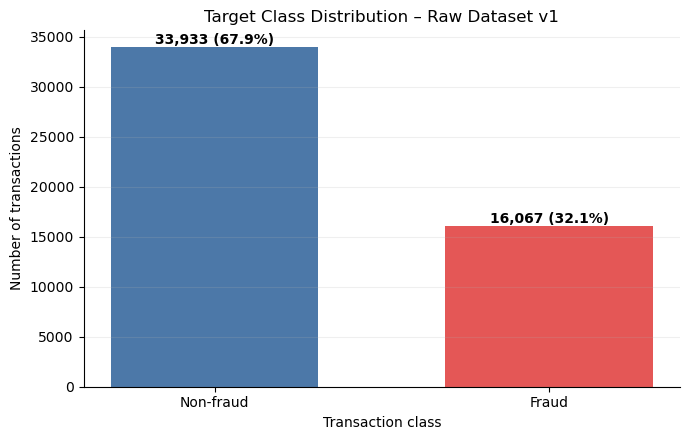

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

class_counts = (
    raw_df[TARGET_COLUMN]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename(index={0: "Non-fraud", 1: "Fraud"})
)
class_percentages = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=["#4C78A8", "#E45756"],
    width=0.62,
)

for bar, count, percentage in zip(bars, class_counts, class_percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,} ({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_title("Target Class Distribution – Raw Dataset v1")
ax.set_xlabel("Transaction class")
ax.set_ylabel("Number of transactions")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 4. EDA Interpretation of the explicit rule audit

The rule is **not** a candidate model and is **not** eligible for champion selection. It is recorded only as evidence that `Risk_Score` participates in apparent target construction. `Risk_Score` is therefore excluded from all valid Model A and Model B runs.
`Failed_Transaction_Count_7d` is retained under the documented assumption that it is a historical value available before the current transaction is scored. This assumption must be confirmed using the dataset documentation or teaching team.

In [7]:
with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_data_quality_leakage_audit"):
    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "data_quality_leakage_audit",
        "eligible_for_champion": "false",
        "risk_score_decision": "excluded_from_modelling",
    })
    mlflow.log_metrics({
        "fraud_rate": audit_summary["fraud_rate"],
        "imbalance_ratio": audit_summary["nonfraud_to_fraud_ratio"],
        "explicit_rule_match_rate": audit_summary["explicit_rule_match_rate"],
        "weekend_mismatch_rate": audit_summary["weekend_mismatch_rate"],
    })
    mlflow.log_params({
        "rows": audit_summary["rows"],
        "columns": audit_summary["columns"],
        "missing_values": audit_summary["missing_values"],
        "duplicate_rows": audit_summary["duplicate_rows"],
        "explicit_rule": audit_summary["explicit_rule"],
    })
    mlflow.log_artifact("data_quality_and_leakage_audit.json", artifact_path="data_audit")

🏃 View run team07_s701_data_quality_leakage_audit at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/b1c8d60f73434c6a8eb60ad779eadb07
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


## 5. Feature engineering : Explicit deployable feature policy and timestamp remediation

In [8]:
FEATURE_POLICY_NAME = "deployable_v2_exclude_risk_score_keep_historical_failed_count"
IDENTIFIER_COLUMNS = ["Transaction_ID", "User_ID"]
LEAKAGE_EXCLUDED_COLUMNS = ["Risk_Score"]
REPLACED_DATA_QUALITY_COLUMNS = ["Is_Weekend"]
RAW_TIME_COLUMN = "Timestamp"

# Inputs expected from the future application. IDs, supplied Risk_Score, supplied Is_Weekend,
# and target are deliberately absent.
RAW_INFERENCE_COLUMNS = [
    column for column in raw_df.columns
    if column not in IDENTIFIER_COLUMNS + LEAKAGE_EXCLUDED_COLUMNS
    + REPLACED_DATA_QUALITY_COLUMNS + [TARGET_COLUMN]
]

def prepare_deployable_features(frame):
    result = frame.copy()
    timestamp = pd.to_datetime(result[RAW_TIME_COLUMN], errors="raise")
    result["Transaction_Hour"] = timestamp.dt.hour
    result["Transaction_DayOfWeek"] = timestamp.dt.dayofweek
    result["Transaction_Month"] = timestamp.dt.month
    result["Derived_Is_Weekend"] = (timestamp.dt.dayofweek >= 5).astype(int)
    result["Transaction_Hour_Sin"] = np.sin(2 * np.pi * result["Transaction_Hour"] / 24)
    result["Transaction_Hour_Cos"] = np.cos(2 * np.pi * result["Transaction_Hour"] / 24)
    return result.drop(columns=
        IDENTIFIER_COLUMNS + LEAKAGE_EXCLUDED_COLUMNS
        + REPLACED_DATA_QUALITY_COLUMNS + [RAW_TIME_COLUMN, TARGET_COLUMN],
        errors="ignore",
    )

X = prepare_deployable_features(raw_df)
y = raw_df[TARGET_COLUMN].astype(int)
CATEGORICAL_COLUMNS = X.select_dtypes(include=["object", "category"]).columns.tolist()
NUMERIC_COLUMNS = [column for column in X.columns if column not in CATEGORICAL_COLUMNS]

feature_policy = {
    "source_dataset_version": RAW_DATASET_VERSION,
    "processed_dataset_version": PROCESSED_DATASET_VERSION,
    "name": FEATURE_POLICY_NAME,
    "risk_score_excluded": True,
    "failed_transaction_count_included": True,
    "failed_count_availability": "assumed_available_before_current_transaction",
    "supplied_is_weekend_excluded": True,
    "timestamp_engineered": True,
    "identifiers_excluded": IDENTIFIER_COLUMNS,
    "raw_inference_columns": RAW_INFERENCE_COLUMNS,
    "model_feature_columns": X.columns.tolist(),
}
Path("feature_policy.json").write_text(json.dumps(feature_policy, indent=2), encoding="utf-8")

print(json.dumps(feature_policy, indent=2))
print("Categorical:", CATEGORICAL_COLUMNS)
print("Numeric:", NUMERIC_COLUMNS)

print("Feature-engineered dataset shape:", X.shape)
print("\nFirst 5 feature-engineered records:")
display(X.head(5))

{
  "source_dataset_version": "fraud_dataset_50k_v1",
  "processed_dataset_version": "fraud_features_v2",
  "name": "deployable_v2_exclude_risk_score_keep_historical_failed_count",
  "risk_score_excluded": true,
  "failed_transaction_count_included": true,
  "failed_count_availability": "assumed_available_before_current_transaction",
  "supplied_is_weekend_excluded": true,
  "timestamp_engineered": true,
  "identifiers_excluded": [
    "Transaction_ID",
    "User_ID"
  ],
  "raw_inference_columns": [
    "Transaction_Amount",
    "Transaction_Type",
    "Timestamp",
    "Account_Balance",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "IP_Address_Flag",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Avg_Transaction_Amount_7d",
    "Failed_Transaction_Count_7d",
    "Card_Type",
    "Card_Age",
    "Transaction_Distance",
    "Authentication_Method"
  ],
  "model_feature_columns": [
    "Transaction_Amount",
    "Transaction_Type",
    "Account_

,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,...,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Transaction_Hour,Transaction_DayOfWeek,Transaction_Month,Derived_Is_Weekend,Transaction_Hour_Sin,Transaction_Hour_Cos
0,39.79,POS,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,...,Amex,65,883.17,Biometric,19,0,8,0,-0.965926,0.258819
1,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,0,13,478.76,...,Mastercard,186,2203.36,Password,4,2,6,0,0.866025,0.500000
2,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,...,Visa,226,1909.29,Biometric,15,1,6,0,-0.707107,-0.707107
3,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,0,8,182.48,...,Visa,76,1311.86,OTP,0,3,12,0,0.000000,1.000000
4,31.28,POS,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,...,Mastercard,140,966.98,Password,23,5,11,1,-0.258819,0.965926


## 6. Stratified 60/20/20 split and save datasets to S3

Create leakage-safe, stratified train, validation, and test splits. Store the unchanged source dataset as raw **v1**, and store the feature-engineered splits together as processed **v2**.

In [9]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_validation, y_train, y_validation = train_test_split(X_train_val, y_train_val, test_size=0.25,stratify=y_train_val, random_state=RANDOM_STATE)

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(y_train), "fraud_count": int(y_train.sum()), "fraud_rate": y_train.mean()},
    {"split": "validation", "rows": len(y_validation), "fraud_count": int(y_validation.sum()), "fraud_rate": y_validation.mean()},
    {"split": "test", "rows": len(y_test), "fraud_count": int(y_test.sum()), "fraud_rate": y_test.mean()}])
display(split_summary)

s3.upload_file(str(DATASET_PATH),
    CLASS_BUCKET,
    f"{RAW_DATA_STORE_PREFIX}/fraud_dataset.csv")

for filename, frame in {
    "X_train.csv": X_train,
    "y_train.csv": y_train.to_frame(TARGET_COLUMN),
    "X_validation.csv": X_validation,
    "y_validation.csv": y_validation.to_frame(TARGET_COLUMN),
    "X_test.csv": X_test,
    "y_test.csv": y_test.to_frame(TARGET_COLUMN),
}.items():
    s3.put_object(
        Bucket=CLASS_BUCKET,
        Key=f"{PROCESSED_DATA_STORE_PREFIX}/{filename}",
        Body=frame.to_csv(index=False).encode("utf-8"),
    )

print("Raw v1 saved under:", f"s3://{CLASS_BUCKET}/{RAW_DATA_STORE_PREFIX}/")
print("Processed v2 saved under:", f"s3://{CLASS_BUCKET}/{PROCESSED_DATA_STORE_PREFIX}/")

,split,rows,fraud_count,fraud_rate
0,train,30000,9641,0.321367
1,validation,10000,3213,0.321300
2,test,10000,3213,0.321300


Raw v1 saved under: s3://nyp-26s1-iti113/iti113/team07/data/fraud_dataset_50k_v1/raw/
Processed v2 saved under: s3://nyp-26s1-iti113/iti113/team07/data/fraud_features_v2/processed/


## 7. Model Preprocessing : Common preprocessing, Evaluation and MLflow helpers

In [10]:
import matplotlib.pyplot as plt
from mlflow.models import infer_signature
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score,
    precision_score,
    recall_score, roc_auc_score, roc_curve, RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_preprocessor(scale_numeric):
    return ColumnTransformer([
        ("numeric", StandardScaler() if scale_numeric else "passthrough", NUMERIC_COLUMNS),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_COLUMNS),
    ])

def threshold_at_fixed_fpr(y_true, probabilities, max_fpr):
    fpr, tpr, thresholds = roc_curve(y_true, probabilities)
    eligible = np.where((fpr <= max_fpr) & np.isfinite(thresholds))[0]
    if len(eligible) == 0:
        return 1.0
    best_recall = tpr[eligible].max()
    tied = eligible[tpr[eligible] == best_recall]
    return float(thresholds[tied].max())

def evaluation_metrics(y_true, probabilities, threshold, prefix):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if fp + tn else 0.0
    return {
        f"{prefix}_accuracy": float(accuracy_score(y_true, predictions)),
        f"{prefix}_precision": float(precision_score(y_true, predictions, zero_division=0)),
        f"{prefix}_recall": float(recall_score(y_true, predictions, zero_division=0)),
        f"{prefix}_f1": float(f1_score(y_true, predictions, zero_division=0)),
        f"{prefix}_fpr": float(fpr),
        f"{prefix}_alert_rate": float(predictions.mean()),
        f"{prefix}_auc_roc": float(roc_auc_score(y_true, probabilities)),
    }

def threshold_sensitivity_table(y_true, probabilities, fpr_budgets=(0.01, 0.02, 0.03, 0.04, 0.05)):
    """Show the recall/quality trade-off without using the test set for tuning."""
    rows = []
    for budget in fpr_budgets:
        threshold = threshold_at_fixed_fpr(y_true, probabilities, budget)
        metrics = evaluation_metrics(y_true, probabilities, threshold, "validation")
        rows.append({
            "fpr_budget": budget,
            "decision_threshold": threshold,
            "recall": metrics["validation_recall"],
            "actual_fpr": metrics["validation_fpr"],
            "precision": metrics["validation_precision"],
            "f1": metrics["validation_f1"],
            "alert_rate": metrics["validation_alert_rate"],
            "false_alerts_per_10k_legitimate": round(metrics["validation_fpr"] * 10_000),
        })
    return pd.DataFrame(rows)

def evaluate_on_validation(model):
    probabilities = model.predict_proba(X_validation)[:, 1]
    threshold = threshold_at_fixed_fpr(y_validation, probabilities, VALIDATION_FPR_TARGET)
    return threshold, evaluation_metrics(y_validation, probabilities, threshold, "validation")

def log_plots(model, title):
    probabilities = model.predict_proba(X_validation)[:, 1]
    threshold = threshold_at_fixed_fpr(y_validation, probabilities, VALIDATION_FPR_TARGET)
    predictions = (probabilities >= threshold).astype(int)
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(y_validation, predictions, display_labels=["Non-fraud", "Fraud"], ax=ax)
        ax.set_title(f"Confusion Matrix - {title}"); fig.tight_layout(); fig.savefig(tmp / "confusion_matrix.png", dpi=120); plt.close(fig)
        fig, ax = plt.subplots(figsize=(5, 4))
        RocCurveDisplay.from_predictions(y_validation, probabilities, ax=ax)
        ax.set_title(f"ROC Curve - {title}"); fig.tight_layout(); fig.savefig(tmp / "roc_curve.png", dpi=120); plt.close(fig)
        mlflow.log_artifacts(str(tmp), artifact_path="plots")

def log_model_pipeline(model):
    example = X_validation.head(5)
    mlflow.sklearn.log_model(
        sk_model=model, name="model",
        signature=infer_signature(example, model.predict_proba(example)),
        input_example=example,
        # skops rejects XGBoost's internal Booster/XGBClassifier types as
        # untrusted. Cloudpickle safely serialises this locally trained pipeline.
        serialization_format="cloudpickle",
    )

candidate_records = []

print("Common preprocessing, evaluation and MLflow helpers are ready.")
print("Numeric columns:", len(NUMERIC_COLUMNS))
print("Categorical columns:", len(CATEGORICAL_COLUMNS))
print("Validation FPR target:", VALIDATION_FPR_TARGET)
print("Final maximum allowed FPR:", MAX_FALSE_POSITIVE_RATE)

Common preprocessing, evaluation and MLflow helpers are ready.
Numeric columns: 15
Categorical columns: 6
Validation FPR target: 0.04
Final maximum allowed FPR: 0.05


## 8. Baseline Heuristic used only as a benchmark; the exact target rule is diagnostic only

The exact 100% rule involving `Risk_Score` is a leakage diagnostic only. The deployable heuristic below excludes `Risk_Score` and uses a preliminary business rule based on assumed pre-transaction history. It is a benchmark, not a champion candidate.

In [11]:
def deployable_heuristic(frame):
    return (
        (frame["Failed_Transaction_Count_7d"] >= 3)
        | ((frame["IP_Address_Flag"] == 1) & (frame["Previous_Fraudulent_Activity"] == 1))
    ).astype(int)

heuristic_predictions = deployable_heuristic(X_validation)
heuristic_probabilities = heuristic_predictions.astype(float)
heuristic_metrics = evaluation_metrics(y_validation, heuristic_probabilities, 0.5, "validation")

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_deployable_business_heuristic"):
    mlflow.set_tags({
        **COMMON_TAGS,
        "run_type": "business_heuristic_baseline",
        "eligible_for_champion": "false",
        "feature_policy": FEATURE_POLICY_NAME,
        "risk_score_excluded": "true",
    })
    mlflow.log_param("rule", "failed_count_7d >= 3 OR (ip_flag == 1 AND previous_fraud == 1)")
    mlflow.log_metrics(heuristic_metrics)

print(pd.Series(heuristic_metrics))

🏃 View run team07_s701_deployable_business_heuristic at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/f2407a3cdacd489daf4a7780f83172e6
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
validation_accuracy      0.737800
validation_precision     0.574302
validation_recall        0.710862
validation_f1            0.635327
validation_fpr           0.249447
validation_alert_rate    0.397700
validation_auc_roc       0.730707
dtype: float64


## 9. Model A - Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

LR_GRID = [
    {"C": 0.1, "class_weight": None},
    {"C": 1.0, "class_weight": None},
    {"C": 0.1, "class_weight": "balanced"},
    {"C": 1.0, "class_weight": "balanced"},
]

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_model_a_logistic_tuning") as parent:
    mlflow.set_tags({**COMMON_TAGS, "model_family": "Model_A", "algorithm": "LogisticRegression", "run_role": "tuning_parent"})
    for index, grid_params in enumerate(LR_GRID, 1):
        # LogisticRegression uses L2 regularisation by default. Do not pass
        # penalty="l2": that spelling is deprecated in scikit-learn >= 1.8.
        params = {
            **grid_params, "solver": "lbfgs",
            "max_iter": 2000, "random_state": RANDOM_STATE,
        }
        run_name = f"logistic_candidate_{index:02d}"
        with mlflow.start_run(run_name=run_name, nested=True) as run:
            mlflow.set_tags({
                **COMMON_TAGS, "model_family": "Model_A", "algorithm": "LogisticRegression",
                "feature_policy": FEATURE_POLICY_NAME, "risk_score_excluded": "true",
                "failed_count_included": "true", "eligible_for_champion": "true",
            })
            mlflow.log_params(params)
            model = Pipeline([
                ("preprocess", make_preprocessor(scale_numeric=True)),
                ("classifier", LogisticRegression(**params)),
            ])
            model.fit(X_train, y_train)
            threshold, metrics = evaluate_on_validation(model)
            mlflow.log_param("decision_threshold", threshold)
            mlflow.log_metrics(metrics)
            log_plots(model, run_name)
            log_model_pipeline(model)
            candidate_records.append({
                "run_id": run.info.run_id, "run_name": run_name,
                "model_family": "Model_A", "algorithm": "LogisticRegression",
                "params": params, "decision_threshold": threshold, **metrics,
            })
            print(
                run_name,
                "recall=", round(metrics["validation_recall"], 6),
                "fpr=", round(metrics["validation_fpr"], 6),
                "f1=", round(metrics["validation_f1"], 6),
            )

/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/25 17:26:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during de

logistic_candidate_01 recall= 0.630252 fpr= 0.039045 f1= 0.735962
🏃 View run logistic_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/d20990a400764214a5f030b117412aaa
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/25 17:26:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during de

logistic_candidate_02 recall= 0.630252 fpr= 0.039929 f1= 0.735161
🏃 View run logistic_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/cb8c0798cef84f808fdaaee84b63a7d1
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/25 17:26:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during de

logistic_candidate_03 recall= 0.631186 fpr= 0.039782 f1= 0.735983
🏃 View run logistic_candidate_03 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/073c78b422604200acf30c8b35dbdc13
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/25 17:26:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during de

logistic_candidate_04 recall= 0.630875 fpr= 0.039782 f1= 0.735753
🏃 View run logistic_candidate_04 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/d00667e0c6964729ad78d1cff6d615a8
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
🏃 View run team07_s701_model_a_logistic_tuning at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/adeb7adc3b9b474bb955de01f4612c53
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


## 10. Model B - XGBoost tuning
Three representative tree structures are tested with `scale_pos_weight=1.0` and with the observed class ratio, producing six XGBoost candidates. This bounded search covers small, medium and deeper models while keeping the experiment understandable and computationally reasonable. Each candidate is evaluated once using the stricter **4% validation FPR target**; the final deployment gate remains **5% test FPR**.


In [13]:
from xgboost import XGBClassifier

observed_weight = float((y_train == 0).sum() / (y_train == 1).sum())

# Compact, bounded search. Every structure is tested without class weighting
# and with the observed training-class ratio.
XGB_STRUCTURES = [
    {"n_estimators": 150, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 1},
    {"n_estimators": 250, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.9, "colsample_bytree": 0.9, "min_child_weight": 3},
    {"n_estimators": 400, "max_depth": 5, "learning_rate": 0.02, "subsample": 0.85, "colsample_bytree": 0.85, "min_child_weight": 3},
]

XGB_GRID = [
    {**structure, "scale_pos_weight": weight}
    for structure in XGB_STRUCTURES
    for weight in (1.0, observed_weight)
]

print("Observed scale_pos_weight:", observed_weight)
print("Number of XGBoost candidates:", len(XGB_GRID))
print("Validation FPR target:", VALIDATION_FPR_TARGET)

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_model_b_xgboost_tuning") as parent:
    mlflow.set_tags({
        **COMMON_TAGS,
        "model_family": "Model_B",
        "algorithm": "XGBoost",
        "run_role": "tuning_parent",
        "search_scope": "compact_v3",
    })
    mlflow.log_param("observed_scale_pos_weight", observed_weight)
    mlflow.log_param("candidate_count", len(XGB_GRID))

    for index, grid_params in enumerate(XGB_GRID, 1):
        params = {
            **grid_params,
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
        run_name = f"xgboost_candidate_{index:02d}"

        with mlflow.start_run(run_name=run_name, nested=True) as run:
            mlflow.set_tags({
                **COMMON_TAGS,
                "model_family": "Model_B",
                "algorithm": "XGBoost",
                "feature_policy": FEATURE_POLICY_NAME,
                "risk_score_excluded": "true",
                "failed_count_included": "true",
                "eligible_for_champion": "true",
                "search_scope": "compact_v3",
            })
            mlflow.log_params(params)

            model = Pipeline([
                ("preprocess", make_preprocessor(scale_numeric=False)),
                ("classifier", XGBClassifier(**params)),
            ])

            model.fit(X_train, y_train)
            threshold, metrics = evaluate_on_validation(model)
            mlflow.log_param("decision_threshold", threshold)
            mlflow.log_metrics(metrics)
            log_plots(model, run_name)
            log_model_pipeline(model)

            candidate_records.append({
                "run_id": run.info.run_id,
                "run_name": run_name,
                "model_family": "Model_B",
                "algorithm": "XGBoost",
                "params": params,
                "decision_threshold": threshold,
                **metrics,
            })

            print(
                run_name,
                "recall=", round(metrics["validation_recall"], 6),
                "fpr=", round(metrics["validation_fpr"], 6),
                "f1=", round(metrics["validation_f1"], 6),
            )

Observed scale_pos_weight: 2.1117104034851155
Number of XGBoost candidates: 6
Validation FPR target: 0.04


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/25 17:26:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during de

xgboost_candidate_01 recall= 0.628385 fpr= 0.037867 f1= 0.735653
🏃 View run xgboost_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/525f0b8857104987b08c87698e4bac4b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/25 17:27:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during de

xgboost_candidate_02 recall= 0.629007 fpr= 0.038161 f1= 0.735846
🏃 View run xgboost_candidate_02 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/38b214f3cd024ba2a09fd59af5066bed
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


...

xgboost_candidate_04 recall= 0.628696 fpr= 0.036835 f1= 0.736823
🏃 View run xgboost_candidate_04 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/823b2d393d004bde8e835c79573df27c
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/25 17:27:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during de

xgboost_candidate_05 recall= 0.631186 fpr= 0.039193 f1= 0.736517
🏃 View run xgboost_candidate_05 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/21825ef39b7c41bdadc838f378ae6c2f
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


/opt/conda/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/25 17:27:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during de

xgboost_candidate_06 recall= 0.630875 fpr= 0.037867 f1= 0.737493
🏃 View run xgboost_candidate_06 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/1819847ebb234908827285a2ba9014a8
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
🏃 View run team07_s701_model_b_xgboost_tuning at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/4b726d08b74042dca898dce1a1bedd2f
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


## 11. Compares candidates, selects the champion and fixes its threshold
Compares candidates, selects the champion and fixes its threshold

The notebook now evaluates **10 candidates in total**: four Logistic Regression candidates and six XGBoost candidates. Only candidates with validation FPR at or below the stricter **4% operating target** are eligible. Selection prioritises highest recall, followed by lower FPR, higher F1 and higher precision. ROC-AUC is retained only as a secondary diagnostic and is not a selection objective.

The probability threshold is estimated from validation predictions. The sensitivity table documents how recall, precision, alert rate and expected false alerts change from a 1% to 5% FPR budget, with 4% selected to provide headroom beneath the unchanged 5% final gate. The test set remains excluded from threshold selection.

In [14]:
comparison = pd.DataFrame(candidate_records)

eligible_candidates = comparison[
    comparison["validation_fpr"] <= VALIDATION_FPR_TARGET
].copy()

if eligible_candidates.empty:
    raise RuntimeError(
        f"No candidate satisfied validation FPR <= {VALIDATION_FPR_TARGET:.2%}."
    )

eligible_candidates = eligible_candidates.sort_values(
    ["validation_recall", "validation_fpr", "validation_f1", "validation_precision", "model_family"],
    ascending=[False, True, False, False, True],
).reset_index(drop=True)

display_columns = [
    "model_family", "algorithm", "run_name", "validation_recall", "validation_fpr",
    "validation_precision", "validation_f1", "decision_threshold",
]

print("All candidates:", len(comparison))
print(f"Candidates satisfying validation FPR <= {VALIDATION_FPR_TARGET:.0%}:", len(eligible_candidates))
display(eligible_candidates[display_columns])

champion = eligible_candidates.iloc[0].to_dict()
BEST_RUN_ID = champion["run_id"]
BEST_RUN_NAME = champion["run_name"]
BEST_MODEL_FAMILY = champion["model_family"]
BEST_ALGORITHM = champion["algorithm"]
BEST_PARAMS = champion["params"]
BEST_THRESHOLD = float(champion["decision_threshold"])
BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/model"

print("Champion:", BEST_MODEL_FAMILY, BEST_ALGORITHM, BEST_RUN_NAME)
print("Validation recall:", champion["validation_recall"])
print("Validation FPR:", champion["validation_fpr"])
print("Decision threshold:", BEST_THRESHOLD)

# Lecturer-feedback analysis: make the threshold trade-off explicit.
validation_champion_model = mlflow.sklearn.load_model(BEST_MODEL_URI)
validation_probabilities = validation_champion_model.predict_proba(X_validation)[:, 1]
threshold_tradeoff = threshold_sensitivity_table(y_validation, validation_probabilities)
threshold_tradeoff["selected_operating_point"] = np.isclose(
    threshold_tradeoff["fpr_budget"], VALIDATION_FPR_TARGET
)

print("\nValidation threshold sensitivity (no test data used):")
display(threshold_tradeoff.style.format({
    "fpr_budget": "{:.1%}",
    "decision_threshold": "{:.6f}",
    "recall": "{:.2%}",
    "actual_fpr": "{:.2%}",
    "precision": "{:.2%}",
    "f1": "{:.3f}",
    "alert_rate": "{:.2%}",
}))

print("\nThreshold justification:")
print(
    f"The selected probability threshold is {BEST_THRESHOLD:.6f}. It gives the highest "
    f"observed validation recall ({champion['validation_recall']:.2%}) while keeping "
    f"validation FPR ({champion['validation_fpr']:.2%}) within the 4% operating target."
)
print(
    "The earlier 70% recall acceptance target is not supported by the leakage-safe "
    "validation results at this operating point; the 60% prototype recall gate and "
    "5% final FPR gate remain unchanged."
)


All candidates: 10
Candidates satisfying validation FPR <= 4%: 10


,model_family,algorithm,run_name,validation_recall,validation_fpr,validation_precision,validation_f1,decision_threshold
0,Model_B,XGBoost,xgboost_candidate_05,0.631186,0.039193,0.884045,0.736517,0.194696
1,Model_A,LogisticRegression,logistic_candidate_03,0.631186,0.039782,0.882507,0.735983,0.656916
2,Model_B,XGBoost,xgboost_candidate_06,0.630875,0.037867,0.887478,0.737493,0.331009
3,Model_A,LogisticRegression,logistic_candidate_04,0.630875,0.039782,0.882455,0.735753,0.657211
4,Model_A,LogisticRegression,logistic_candidate_01,0.630252,0.039045,0.884279,0.735962,0.495118
5,Model_B,XGBoost,xgboost_candidate_03,0.630252,0.039782,0.882353,0.735294,0.184902
6,Model_A,LogisticRegression,logistic_candidate_02,0.630252,0.039929,0.881969,0.735161,0.495353
7,Model_B,XGBoost,xgboost_candidate_02,0.629007,0.038161,0.886404,0.735846,0.313227
8,Model_B,XGBoost,xgboost_candidate_04,0.628696,0.036835,0.889868,0.736823,0.322619
9,Model_B,XGBoost,xgboost_candidate_01,0.628385,0.037867,0.887083,0.735653,0.179376


Champion: Model_B XGBoost xgboost_candidate_05
Validation recall: 0.6311858076563959
Validation FPR: 0.03919257403860321
Decision threshold: 0.19469599425792694



Validation threshold sensitivity (no test data used):


,fpr_budget,decision_threshold,recall,actual_fpr,precision,f1,alert_rate,false_alerts_per_10k_legitimate,selected_operating_point
0,1.0%,0.217303,61.97%,0.99%,96.74%,0.755,20.58%,99,False
1,2.0%,0.205946,62.37%,1.97%,93.73%,0.749,21.38%,197,False
2,3.0%,0.198878,62.78%,2.99%,90.86%,0.742,22.20%,299,False
3,4.0%,0.194696,63.12%,3.92%,88.40%,0.737,22.94%,392,True
4,5.0%,0.191473,63.40%,4.89%,85.99%,0.730,23.69%,489,False



Threshold justification:
The selected probability threshold is 0.194696. It gives the highest observed validation recall (63.12%) while keeping validation FPR (3.92%) within the 4% operating target.
The earlier 70% recall acceptance target is not supported by the leakage-safe validation results at this operating point; the 60% prototype recall gate and 5% final FPR gate remain unchanged.


## 12. Visual analysis: model selection and operating-threshold trade-off

The first chart compares every eligible candidate using the two operational measures that matter most: recall and FPR. The second chart shows how much recall is achievable as the false-positive budget increases. Together, they justify the 4% validation operating target as a safety margin without relaxing the 5% final FPR limit.


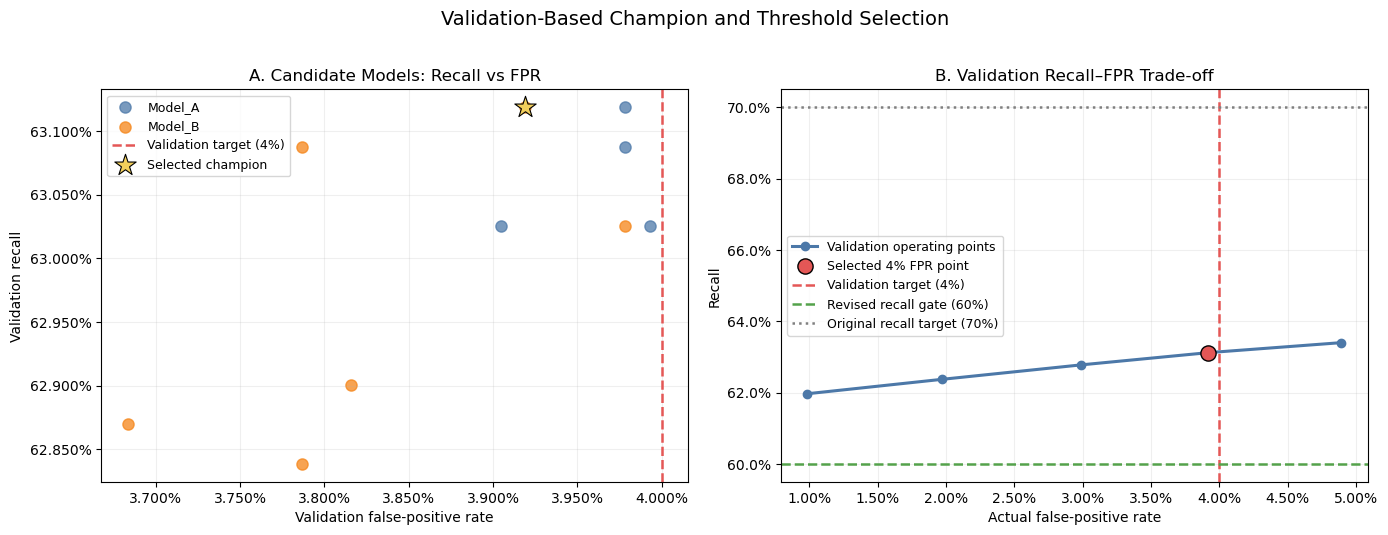

In [15]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# Panel A: compare all model candidates at their validation operating points.
colors = {"Model_A": "#4C78A8", "Model_B": "#F58518"}
for model_family, group in comparison.groupby("model_family"):
    axes[0].scatter(
        group["validation_fpr"],
        group["validation_recall"],
        s=65,
        alpha=0.75,
        color=colors.get(model_family),
        label=model_family,
    )

axes[0].axvline(
    VALIDATION_FPR_TARGET,
    color="#E45756",
    linestyle="--",
    linewidth=1.8,
    label="Validation target (4%)",
)
axes[0].scatter(
    champion["validation_fpr"],
    champion["validation_recall"],
    marker="*",
    color="#F2CF5B",
    edgecolor="black",
    linewidth=0.8,
    s=260,
    label="Selected champion",
    zorder=5,
)
axes[0].set_title("A. Candidate Models: Recall vs FPR")
axes[0].set_xlabel("Validation false-positive rate")
axes[0].set_ylabel("Validation recall")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=9)

# Panel B: show the threshold trade-off 
axes[1].plot(
    threshold_tradeoff["actual_fpr"],
    threshold_tradeoff["recall"],
    marker="o",
    linewidth=2.2,
    color="#4C78A8",
    label="Validation operating points",
)
selected = threshold_tradeoff[threshold_tradeoff["selected_operating_point"]]
axes[1].scatter(
    selected["actual_fpr"],
    selected["recall"],
    color="#E45756",
    edgecolor="black",
    s=120,
    label="Selected 4% FPR point",
    zorder=5,
)
axes[1].axvline(
    VALIDATION_FPR_TARGET,
    color="#E45756",
    linestyle="--",
    linewidth=1.8,
    label="Validation target (4%)",
)
axes[1].axhline(
    MIN_ACCEPTABLE_RECALL,
    color="#54A24B",
    linestyle="--",
    linewidth=1.8,
    label="Revised recall gate (60%)",
)
axes[1].axhline(
    0.70,
    color="#7F7F7F",
    linestyle=":",
    linewidth=1.8,
    label="Original recall target (70%)",
)
axes[1].set_title("B. Validation Recall–FPR Trade-off")
axes[1].set_xlabel("Actual false-positive rate")
axes[1].set_ylabel("Recall")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=9)

fig.suptitle("Validation-Based Champion and Threshold Selection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 13 Final Champion Evaluation on the Held-Out Test Dataset and Error Analysis on Confusion Matrix 

The operating probability threshold is fixed using validation data and applied unchanged to the held-out test set; test labels are **not** used to retune it. Because a prior experiment result has already been inspected, this rerun is documented as a confirmation iteration rather than a first untouched evaluation. The final prototype criteria remain **recall >= 0.60** and **FPR <= 0.05**. 

The confusion matrix translates the final test recall and FPR into counts of detected fraud, missed fraud, correct legitimate decisions and false alerts.

,metric,result,meaning
0,Recall,63.68%,Fraud cases successfully detected
1,False-positive rate,4.01%,Legitimate transactions incorrectly flagged
2,Precision,88.27%,Fraud alerts that are genuinely fraudulent
3,F1 score,73.98%,Balance between recall and precision



Final deployment gate
Recall: 0.636788 >= 0.60 -> True
FPR:    0.040077 <= 0.05 -> True
Deployment ready: True
Gate rationale: The original 0.70 recall gate was not feasible after excluding leakage-prone Risk_Score. Threshold selection uses a 0.04 validation FPR target to provide a generalisation margin. The prototype recall gate remains 0.60 and the final deployment FPR gate remains capped at 0.05.


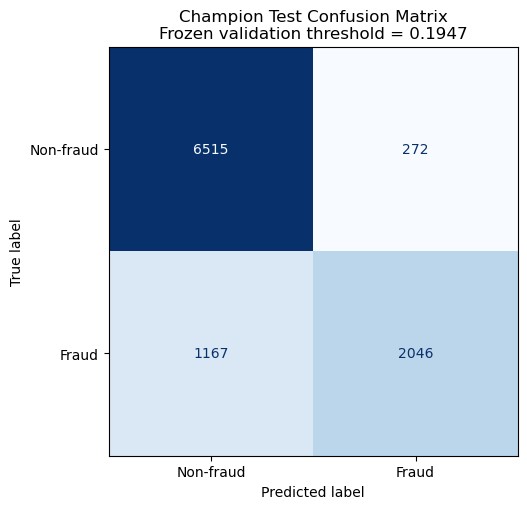

True negatives: 6,515 | False positives: 272
False negatives: 1,167 | True positives: 2,046


In [16]:
from mlflow.tracking import MlflowClient

champion_model = mlflow.sklearn.load_model(BEST_MODEL_URI)
test_probabilities = champion_model.predict_proba(X_test)[:, 1]
test_metrics = evaluation_metrics(y_test, test_probabilities, BEST_THRESHOLD, "test")

client = MlflowClient()
for name, value in test_metrics.items():
    client.log_metric(BEST_RUN_ID, name, value)

recall_passed = test_metrics["test_recall"] >= MIN_ACCEPTABLE_RECALL
fpr_passed = test_metrics["test_fpr"] <= MAX_FALSE_POSITIVE_RATE
deployment_ready = recall_passed and fpr_passed

client.set_tag(BEST_RUN_ID, "champion", "true")
client.set_tag(BEST_RUN_ID, "deployment_ready", str(deployment_ready).lower())
client.set_tag(BEST_RUN_ID, "risk_score_excluded", "true")
client.set_tag(BEST_RUN_ID, "gate_rationale", GATE_RATIONALE)

presentation_test_metrics = pd.DataFrame({
    "metric": ["Recall", "False-positive rate", "Precision", "F1 score"],
    "result": [
        test_metrics["test_recall"],
        test_metrics["test_fpr"],
        test_metrics["test_precision"],
        test_metrics["test_f1"],
    ],
    "meaning": [
        "Fraud cases successfully detected",
        "Legitimate transactions incorrectly flagged",
        "Fraud alerts that are genuinely fraudulent",
        "Balance between recall and precision",
    ],
})
display(presentation_test_metrics.style.format({"result": "{:.2%}"}))

print("\nFinal deployment gate")
print(
    f"Recall: {test_metrics['test_recall']:.6f} >= {MIN_ACCEPTABLE_RECALL:.2f} "
    f"-> {recall_passed}"
)
print(
    f"FPR:    {test_metrics['test_fpr']:.6f} <= {MAX_FALSE_POSITIVE_RATE:.2f} "
    f"-> {fpr_passed}"
)
print("Deployment ready:", deployment_ready)
print("Gate rationale:", GATE_RATIONALE)

if not deployment_ready:
    failed = []
    if not recall_passed:
        failed.append(
            f"recall {test_metrics['test_recall']:.6f} is below {MIN_ACCEPTABLE_RECALL:.2f}"
        )
    if not fpr_passed:
        failed.append(
            f"FPR {test_metrics['test_fpr']:.6f} is above {MAX_FALSE_POSITIVE_RATE:.2f}"
        )
    print("[NOT DEPLOYMENT READY] " + "; ".join(failed))

test_predictions = (test_probabilities >= BEST_THRESHOLD).astype(int)

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Non-fraud", "Fraud"],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=ax,
)
ax.set_title(
    "Champion Test Confusion Matrix\n"
    f"Frozen validation threshold = {BEST_THRESHOLD:.4f}"
)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_predictions, labels=[0, 1]).ravel()
print(f"True negatives: {tn:,} | False positives: {fp:,}")
print(f"False negatives: {fn:,} | True positives: {tp:,}")

## 14. Export the champion for Automated Training, Registry & Deployment Pipeline and print summary results

In [17]:
best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "raw_dataset_version": RAW_DATASET_VERSION,
    "processed_dataset_version": PROCESSED_DATASET_VERSION,
    "raw_dataset_s3_uri": f"s3://{CLASS_BUCKET}/{RAW_DATA_STORE_PREFIX}/fraud_dataset.csv",
    "processed_dataset_s3_prefix": f"s3://{CLASS_BUCKET}/{PROCESSED_DATA_STORE_PREFIX}/",
    "dataset_source_url": DATASET_SOURCE_URL,
    "model_family": BEST_MODEL_FAMILY,
    "algorithm": BEST_ALGORITHM,
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_model_uri": BEST_MODEL_URI,
    "best_parameters": BEST_PARAMS,
    "decision_threshold": BEST_THRESHOLD,
    "validation_fpr_target": VALIDATION_FPR_TARGET,
    "maximum_false_positive_rate": MAX_FALSE_POSITIVE_RATE,
    "minimum_acceptable_recall": MIN_ACCEPTABLE_RECALL,
    "threshold_selection_split": "validation_only",
    "threshold_selection_objective": "maximum_recall_subject_to_validation_fpr_lte_0.04",
    "threshold_tradeoff": threshold_tradeoff.to_dict(orient="records"),
    "gate_rationale": GATE_RATIONALE,
    "deployment_ready": bool(deployment_ready),
    "feature_policy": feature_policy,
    "risk_score_excluded": True,
    "failed_transaction_count_included": True,
    "split_strategy": "stratified_random_60_20_20",
    "random_state": RANDOM_STATE,
    "categorical_columns": CATEGORICAL_COLUMNS,
    "numeric_columns": NUMERIC_COLUMNS,
    "raw_inference_columns": RAW_INFERENCE_COLUMNS,
    "model_feature_columns": X.columns.tolist(),
    "target_column": TARGET_COLUMN,
    "data_audit": audit_summary,
    "validation_metrics": {key: float(value) for key, value in champion.items() if key.startswith("validation_")},
    "test_metrics": test_metrics,
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
}

output_file = Path(f"{TEAM_ID}_best_model.json")
output_file.write_text(json.dumps(best_model_info, indent=2), encoding="utf-8")
print("Saved:", output_file)
#print(json.dumps(best_model_info, indent=2))

print("=" * 72)
print("EXPERIMENTS COMPLETE")
print("=" * 72)
print("Raw dataset version  :", RAW_DATASET_VERSION)
print("Processed data version:", PROCESSED_DATASET_VERSION)
print("Feature policy       :", FEATURE_POLICY_NAME)
print("Risk_Score excluded  : True")
print("Model A              : Logistic Regression")
print("Model B              : XGBoost")
print("Champion             :", BEST_MODEL_FAMILY, "/", BEST_ALGORITHM)
print("Validation recall/FPR:", champion["validation_recall"], "/", champion["validation_fpr"])
print("Test recall/FPR      :", test_metrics["test_recall"], "/", test_metrics["test_fpr"])
print("Recall acceptance gate:", MIN_ACCEPTABLE_RECALL)
print("Validation FPR target :", VALIDATION_FPR_TARGET)
print("Final maximum FPR gate:", MAX_FALSE_POSITIVE_RATE)
print("Probability threshold:", BEST_THRESHOLD)
print("Deployment ready     :", deployment_ready)
print("Gate rationale       :", GATE_RATIONALE)
print("Notebook 03 input    :", output_file)

Saved: team07_best_model.json
EXPERIMENTS COMPLETE
Raw dataset version  : fraud_dataset_50k_v1
Processed data version: fraud_features_v2
Feature policy       : deployable_v2_exclude_risk_score_keep_historical_failed_count
Risk_Score excluded  : True
Model A              : Logistic Regression
Model B              : XGBoost
Champion             : Model_B / XGBoost
Validation recall/FPR: 0.6311858076563959 / 0.03919257403860321
Test recall/FPR      : 0.6367880485527544 / 0.040076617062030355
Recall acceptance gate: 0.6
Validation FPR target : 0.04
Final maximum FPR gate: 0.05
Probability threshold: 0.19469599425792694
Deployment ready     : True
Gate rationale       : The original 0.70 recall gate was not feasible after excluding leakage-prone Risk_Score. Threshold selection uses a 0.04 validation FPR target to provide a generalisation margin. The prototype recall gate remains 0.60 and the final deployment FPR gate remains capped at 0.05.
Notebook 03 input    : team07_best_model.json
